### Computational Guided Inquiry for Modeling Earth's Climate (Neshyba, 2025)

# Cambio Comparisons

## The idea of this CGI
To summarize:

- Cambio 1.0 has the five basic equations of motion, with $CO_2$ fertilization but no other feedbacks
- Cambio 2.0 adds in Henry's Law feedbacks
- Cambio 3.0 adds in ice-albedo feedback
- Cambio 4.0 adds in terrestrial sequestion feedback that reduces $CO_2$ fertilization

Here, the idea is carry out an intercomparison between these models.

## Uploading your climate emissions scenario
As before, you'll need to upload a climate emissions scenario file to the current folder. 

## Learning goals
1. I can summarize differences in Cambio1.0-Cambio4.0, and the reasons for those differences.

In [3]:
import numpy as np
import matplotlib.pyplot as plt; plt.rc("figure", figsize=(12,8))
import meclib.cl as cl

In [5]:
from platform import python_version
print(python_version())

3.10.8


### Loading your favorite scheduled flow
In the cell below, load in your scheduled flows file. It'll be most convenient if you use the following naming convention: 

    time, eps, epsdictionary_from_file = cl.LoadMyScenario('...')

(but of course supplying the name of your own scheduled flows file). 

{'dataframe':             time  emissions
0    1750.000000   0.134987
1    1750.667780   0.136492
2    1751.335559   0.138013
3    1752.003339   0.139552
4    1752.671119   0.141107
..           ...        ...
595  2147.328881   4.000000
596  2147.996661   4.000000
597  2148.664441   4.000000
598  2149.332220   4.000000
599  2150.000000   4.000000

[600 rows x 2 columns], 't_0': 2003, 'eps_0': 9, 't_peak': 2040, 't_decarb': 15, 'k': 0.0166}


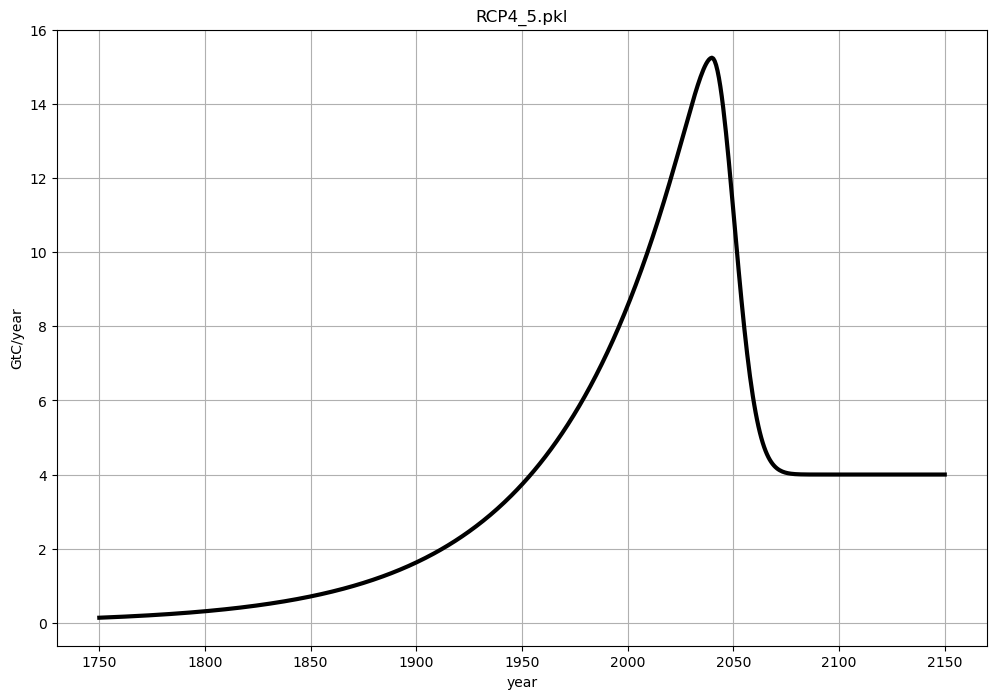

In [4]:
### BEGIN SOLUTION
# Here's loading it in, with graphics
# filename = '../zzz ScenarioLibrary/Peaks_in_2040_default.pkl'
filename = 'RCP4_5.pkl'
# filename = '.2040_peak_scenario_emass.pkl'
# filename = '../zzz ScenarioLibrary/my_low.pkl'
time, eps, epsdictionary_from_file = cl.LoadMyScenario(filename,verbose=True)
### END SOLUTION

### Creating a dictionary for climate parameters
In the cell below, we use the CreateClimateParams function to create a dictionary of climate parameters.

In [6]:
ClimateParams = cl.CreateClimateParams(epsdictionary_from_file)

### Running the various Cambio versions
The cell below runs Cambio versions 1-4.

In [8]:
CS_Cambio1_list = cl.run_Cambio(cl.PropagateClimateState_Cambio1, ClimateParams, time, eps)
CS_Cambio2_list = cl.run_Cambio(cl.PropagateClimateState_Cambio2, ClimateParams, time, eps)
CS_Cambio3_list = cl.run_Cambio(cl.PropagateClimateState_Cambio3, ClimateParams, time, eps)
CS_Cambio4_list = cl.run_Cambio(cl.PropagateClimateState_Cambio4, ClimateParams, time, eps)

### Individual reports
You can run the cell below as-is, or modify it to suit your interests.

Max of Cambio4.0 (T_anomaly) =  3.516940913585054 at time  2150.000000000028
Min of Cambio4.0 (T_anomaly) =  0.0 at time  1750.6677796327212


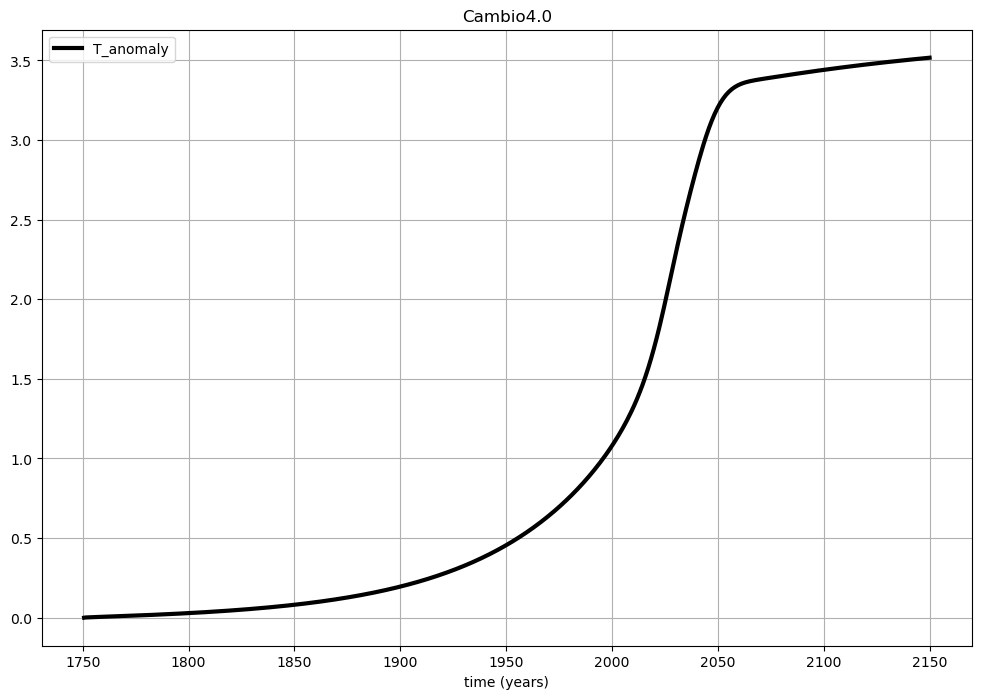

In [10]:
CS_Cambio4_list = cl.run_Cambio(cl.PropagateClimateState_Cambio4, ClimateParams, time, eps)
items_to_plot = ['T_anomaly']
cl.CS_list_plots(CS_Cambio4_list,'Cambio4.0',items_to_plot)

### Comparison plots
The command below uses *cl.CS_list_compare* to compare Cambio1.0 to Cambio4.0 for a selection of data types.

Max of Cambio1.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio1.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio2.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio2.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio1.0 (F_ocean_net) =  0.9291941313067014 at time  2078.5475792988545
Min of Cambio1.0 (F_ocean_net) =  -3.7841732430590582 at time  2040.4841402337433
Max of Cambio2.0 (F_ocean_net) =  0.0 at time  1750.6677796327212
Min of Cambio2.0 (F_ocean_net) =  -4.498095630444212 at time  2040.4841402337433
Max of Cambio1.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio1.0 (F_land_net) =  -6.730245028127882 at time  2055.175292153611
Max of Cambio2.0 (F_land_net) =  0.00032597387897226326 at time  1750.6677796327212
Min of Cambio2.0 (F_land_net) =  -3.62244979101888 at time  2150.000000000028


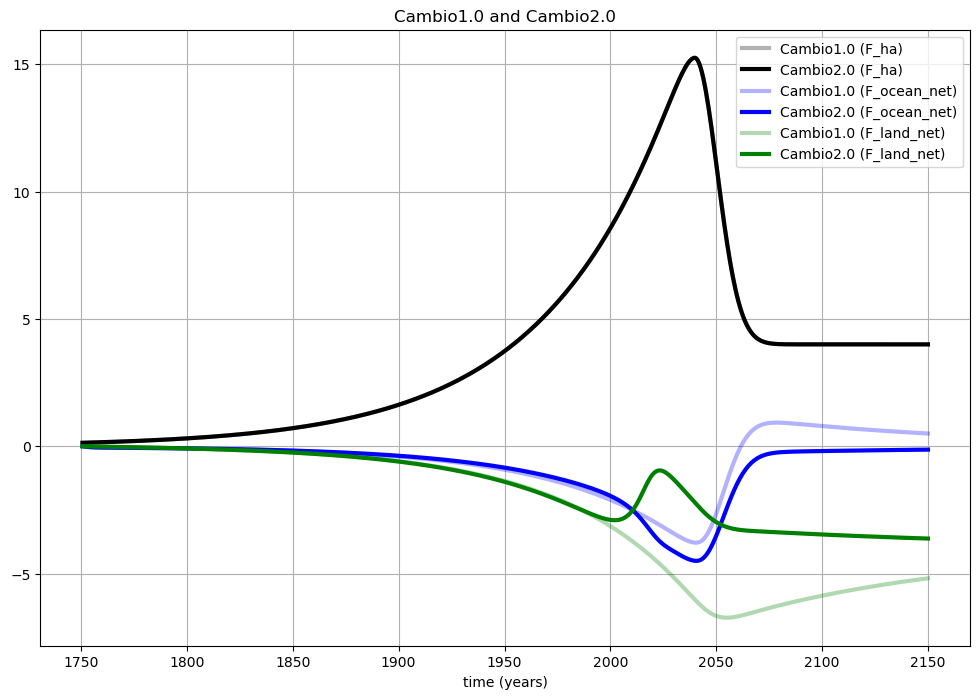

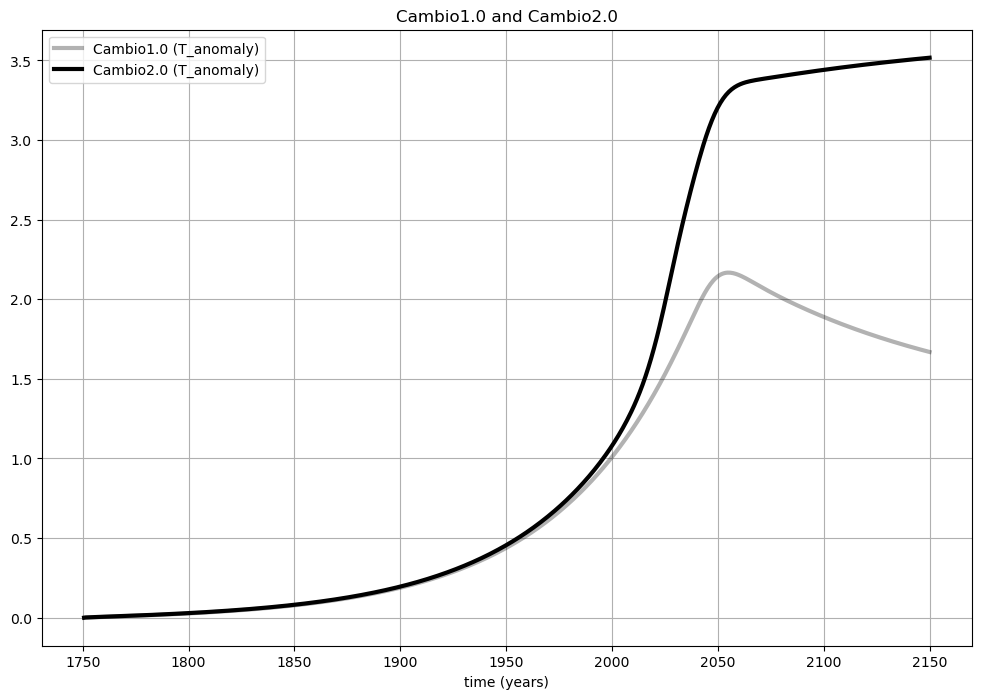

In [17]:
items_to_plot = [['F_ha','F_ocean_net','F_land_net'],'T_anomaly']
cl.CS_list_compare([CS_Cambio1_list,CS_Cambio4_list],['Cambio1.0','Cambio2.0'],items_to_plot)

### Your turn
In the cell below, use *cl.CS_list_compare* to compare Cambio3.0 to Cambio4.0, but add these items to the *items_to_plot* list:

    ['C_atm','C_ocean']
    'albedo'
    'OceanSurfacepH'

Max of Cambio3.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio3.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio4.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio4.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio3.0 (F_ocean_net) =  0.8680876844604626 at time  2077.8797996661333
Min of Cambio3.0 (F_ocean_net) =  -3.053688680215018 at time  2040.4841402337433
Max of Cambio4.0 (F_ocean_net) =  0.0 at time  1750.6677796327212
Min of Cambio4.0 (F_ocean_net) =  -4.498095630444212 at time  2040.4841402337433
Max of Cambio3.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio3.0 (F_land_net) =  -7.077219961181299 at time  2055.175292153611
Max of Cambio4.0 (F_land_net) =  0.00032597387897226326 at time  1750.6677796327212
Min of Cambio4.0 (F_land_net) =  -3.62244979101888 at time  2150.000000000028


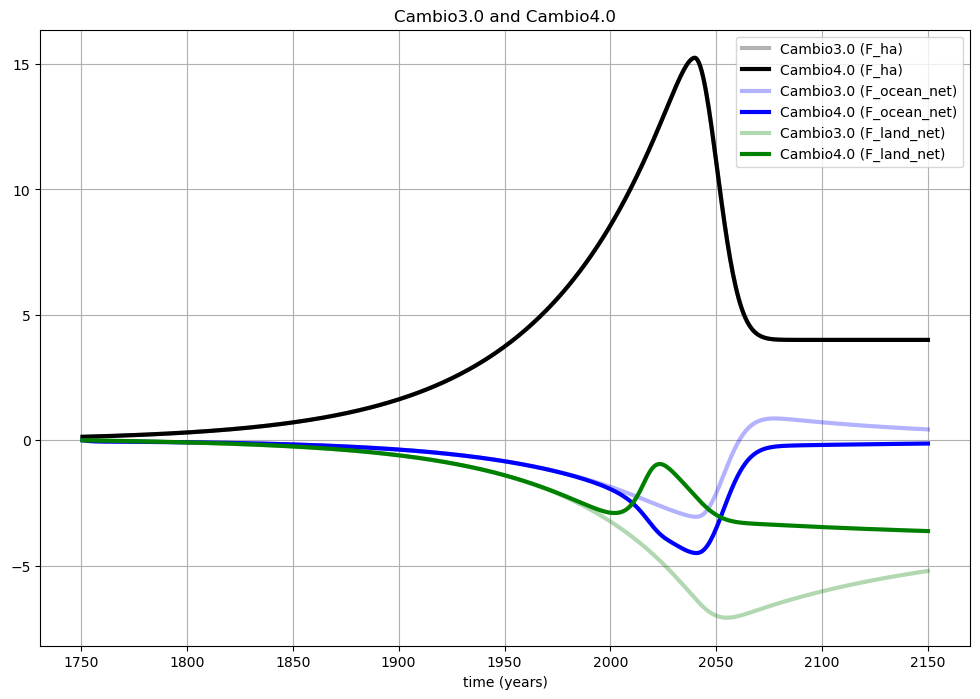

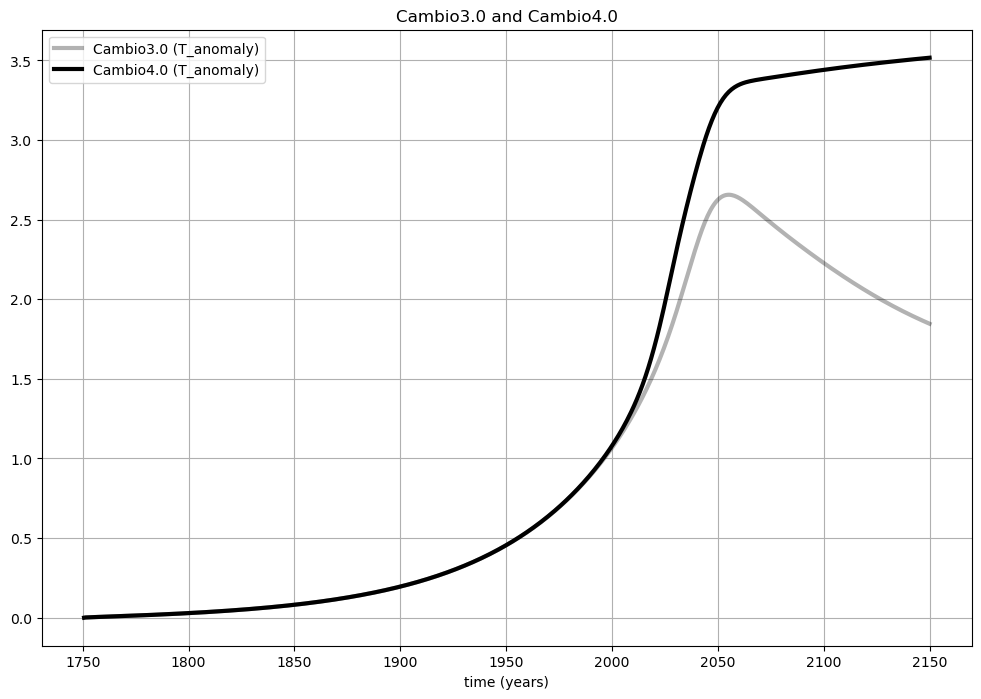

Max of Cambio3.0 (C_atm) =  1038.2239308748153 at time  2054.5075125208896
Min of Cambio3.0 (C_atm) =  590.0911464858788 at time  1750.6677796327212
Max of Cambio4.0 (C_atm) =  1198.148498980305 at time  2150.000000000028
Min of Cambio4.0 (C_atm) =  590.091364164596 at time  1750.6677796327212
Max of Cambio3.0 (C_ocean) =  663.5831393970195 at time  2060.517529215381
Min of Cambio3.0 (C_ocean) =  410.78888417993585 at time  1750.6677796327212
Max of Cambio4.0 (C_ocean) =  748.8772422943533 at time  2150.000000000028
Min of Cambio4.0 (C_ocean) =  410.78888417993585 at time  1750.6677796327212


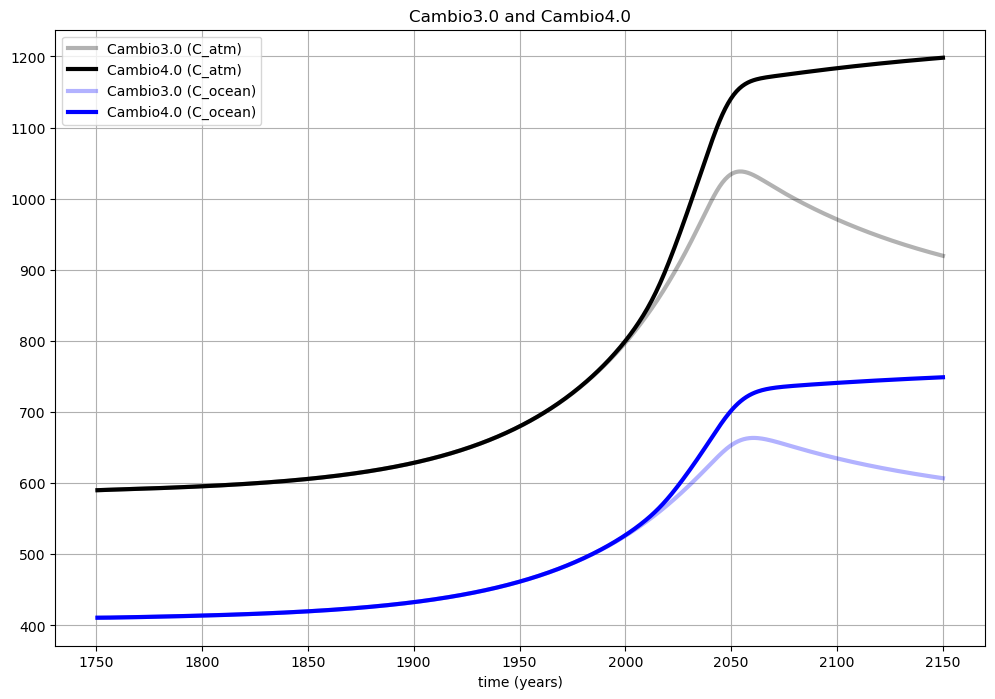

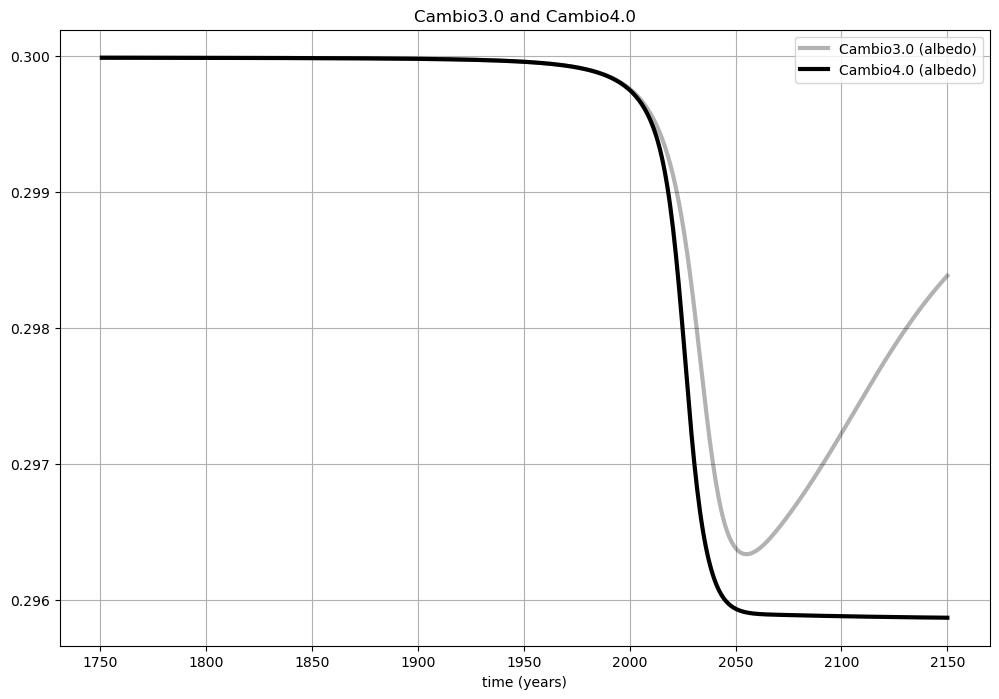

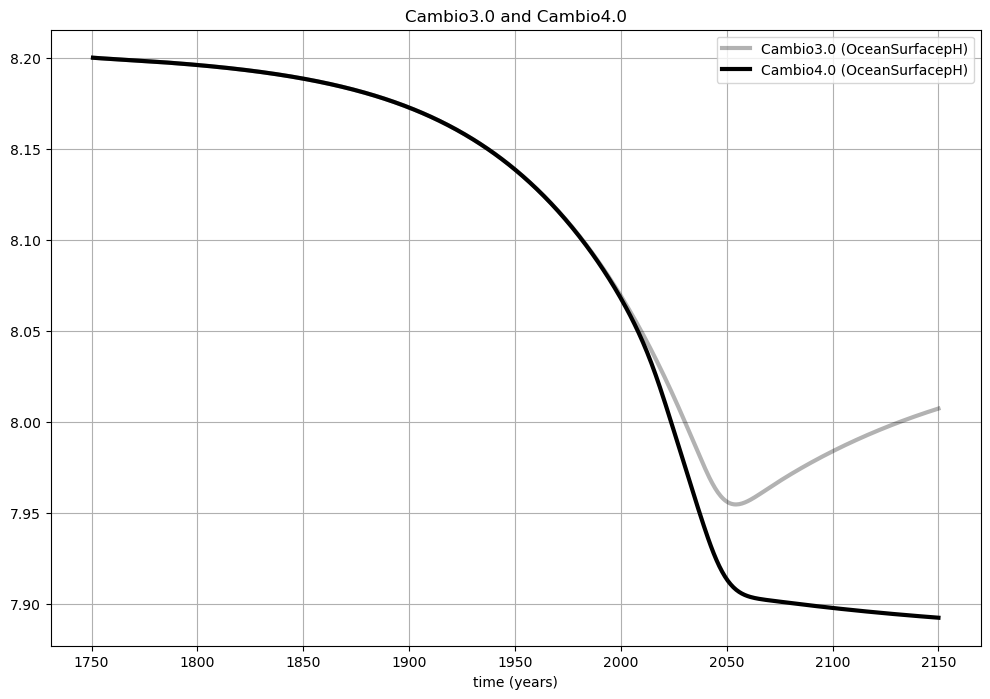

Max of Cambio1.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio1.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio2.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio2.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio1.0 (F_ocean_net) =  0.9291941313067014 at time  2078.5475792988545
Min of Cambio1.0 (F_ocean_net) =  -3.7841732430590582 at time  2040.4841402337433
Max of Cambio2.0 (F_ocean_net) =  0.8836271027937528 at time  2077.8797996661333
Min of Cambio2.0 (F_ocean_net) =  -3.2296460157450326 at time  2039.816360601022
Max of Cambio1.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio1.0 (F_land_net) =  -6.730245028127882 at time  2055.175292153611
Max of Cambio2.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio2.0 (F_land_net) =  -7.018716159163475 at time  2055.175292153611


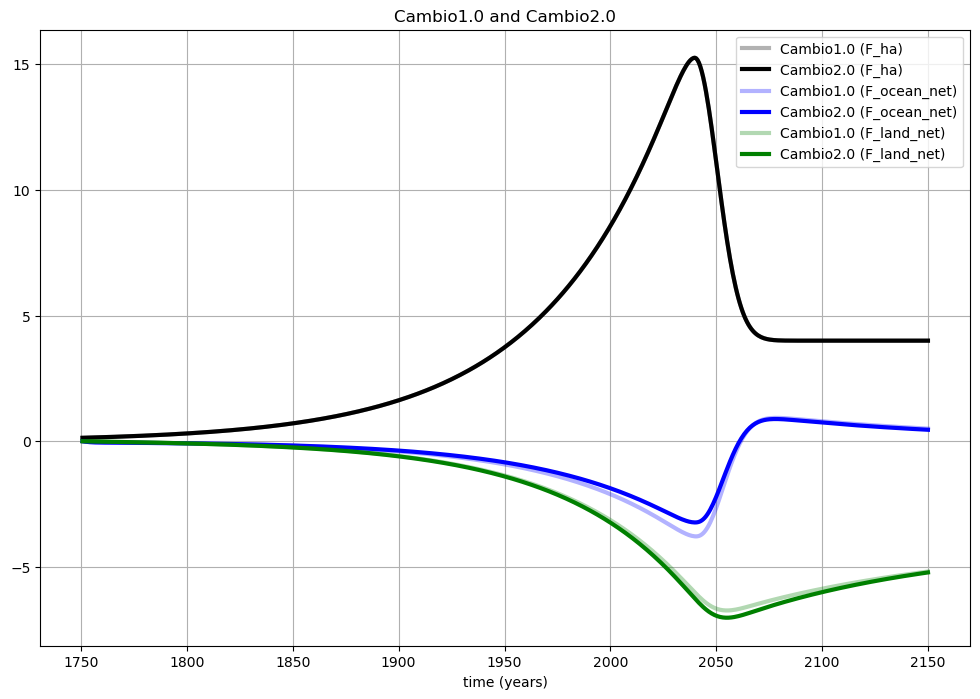

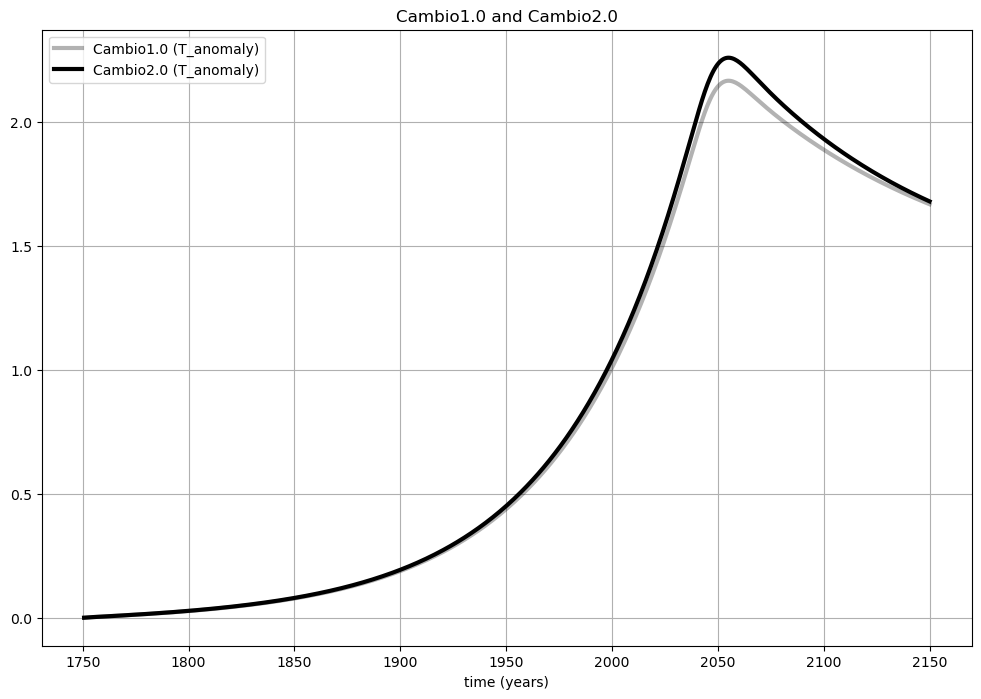

Max of Cambio2.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio2.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio3.0 (F_ha) =  15.252233588429393 at time  2039.816360601022
Min of Cambio3.0 (F_ha) =  0.13649186260348795 at time  1750.6677796327212
Max of Cambio2.0 (F_ocean_net) =  0.8836271027937528 at time  2077.8797996661333
Min of Cambio2.0 (F_ocean_net) =  -3.2296460157450326 at time  2039.816360601022
Max of Cambio3.0 (F_ocean_net) =  0.8680876844604626 at time  2077.8797996661333
Min of Cambio3.0 (F_ocean_net) =  -3.053688680215018 at time  2040.4841402337433
Max of Cambio2.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio2.0 (F_land_net) =  -7.018716159163475 at time  2055.175292153611
Max of Cambio3.0 (F_land_net) =  0.0 at time  1750.6677796327212
Min of Cambio3.0 (F_land_net) =  -7.077219961181299 at time  2055.175292153611


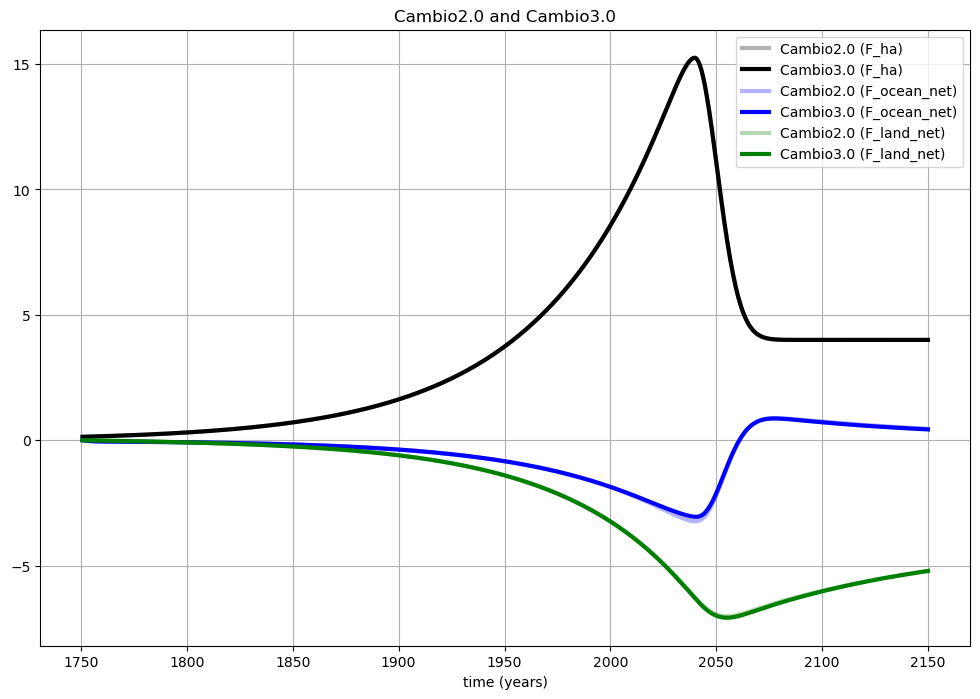

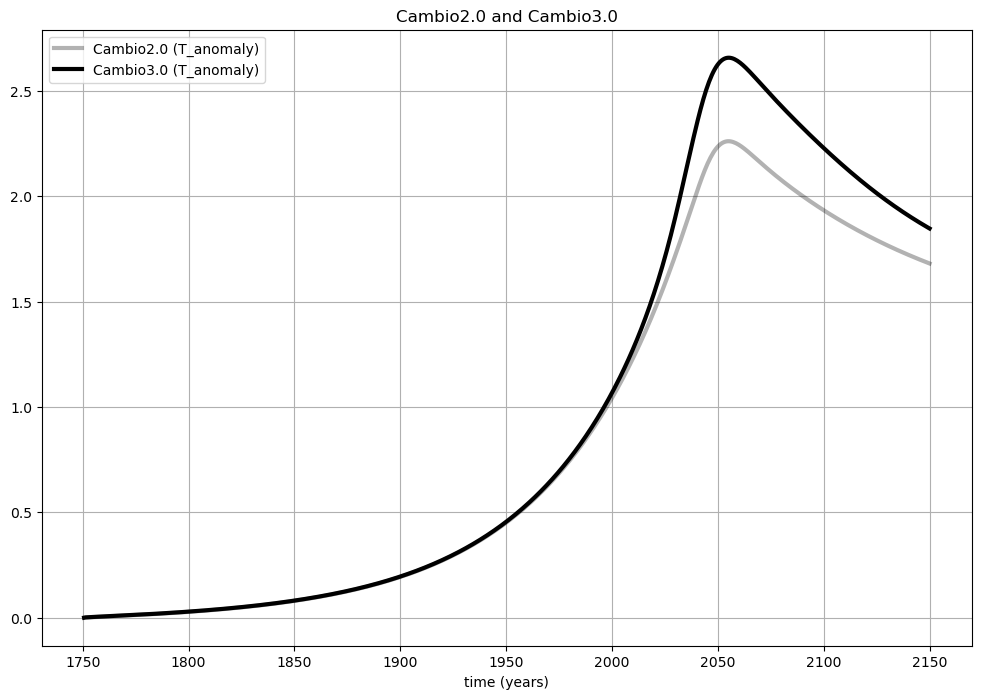

In [22]:
### BEGIN SOLUTION

items_to_plot = [['F_ha','F_ocean_net','F_land_net'],'T_anomaly',['C_atm','C_ocean'],'albedo','OceanSurfacepH']
cl.CS_list_compare([CS_Cambio3_list,CS_Cambio4_list],['Cambio3.0','Cambio4.0'],items_to_plot)
# cl.CS_list_compare([CS_Cambio1_list,CS_Cambio3_list],['Cambio1.0','Cambio3.0'],items_to_plot)

# # Revelle ratio
# CS_Cambio_list = CS_Cambio1_list; R_title = 'Cambio1.0'
# # CS_Cambio_list = CS_Cambio2_list; R_title = 'Cambio2.0'
# # CS_Cambio_list = CS_Cambio3_list; R_title = 'Cambio3.0'
# # CS_Cambio_list = CS_Cambio4_list; R_title = 'Cambio4.0'

# time = cl.CollectClimateTimeSeries(CS_Cambio_list,'time')
# F_ha = cl.CollectClimateTimeSeries(CS_Cambio_list,'F_ha')
# F_ocean_net = cl.CollectClimateTimeSeries(CS_Cambio_list,'F_ocean_net')
# C_atm = cl.CollectClimateTimeSeries(CS_Cambio_list,'C_atm')
# C_ocean = cl.CollectClimateTimeSeries(CS_Cambio_list,'C_ocean')
# C_ocean_preindustrial = C_ocean[0]
# Delta_C_ocean =  C_ocean - C_ocean_preindustrial
# k_oa = ClimateParams['k_oa']; print('k_oa =', k_oa)
# F_atm_net = cl.CollectClimateTimeSeries(CS_Cambio_list,'F_ocean_net')
# d_C_ocean = np.diff(C_ocean)
# denominator = d_C_ocean/C_ocean[1:]

# d_F_ha = F_ha[1:]
# Revelle_A = (d_F_ha/C_atm[1:])/denominator
# d_C_atm = np.diff(C_atm)
# Revelle_B = (d_C_atm/C_atm[1:])/denominator

# plt.figure()
# plt.plot(time[0:-1],Revelle_A,'k',label='Revelle factor using F_ha')
# plt.plot(time[0:-1],Revelle_B,'r',label='Revelle factor using C_atm')
# plt.grid(True)
# plt.xlabel('time (yr)')
# plt.title(R_title)
# plt.legend()
# plt.xlim([1986,2015])
# plt.ylim([0,2])


# Not part of the solution, but for lecture purposes
items_to_plot = [['F_ha','F_ocean_net','F_land_net'],'T_anomaly']
cl.CS_list_compare([CS_Cambio1_list,CS_Cambio2_list],['Cambio1.0','Cambio2.0'],items_to_plot)

items_to_plot = [['F_ha','F_ocean_net','F_land_net'],'T_anomaly']
cl.CS_list_compare([CS_Cambio2_list,CS_Cambio3_list],['Cambio2.0','Cambio3.0'],items_to_plot)



### END SOLUTION

### Pause for analysis
After studying the graphs above, provide in the cell below answers to the following questions. It will be helpful to refer to the max/min printouts as you do so.

1. How much greater is the peak temperature that we can attribute to all feedbacks, compared to none? (i.e., Cambio 4.0 compared to Cambio 1.0)
1. How does the timing of peak temperature increase due to feedbacks? (again, comparing timing of peak temperatures predicted by Cambio 4.0 to Cambio 1.0).
1. How much peak warming can we attribute to terrestrial sequestration feedback alone? (i.e., Cambio 4.0 compared to Cambio 3.0)

### BEGIN SOLUTION

Depends on the scenario, but generally:

1. Peak temperature with all feedbacks is at least one degree higher.
1. Looks like peak temperature is delayed by 5-6 years.
1. Looks like extra 0.6 to 0.8 degrees warming.


### END SOLUTION

### Validating and finishing up
Assuming all this has gone smoothly, don't forget to do a Kernel/Restart & Run All, run the whole notebook, and make sure there aren't any errors.